# Drug Consumption Risk Prediction and Feature Importance Analysis

This project focuses on two primary objectives. The first is to train and evaluate machine learning models capable of identifying individuals or demographic groups at higher risk of drug consumption using demographic information and psychological assessment data. The second objective is to analyze feature importance within the trained models in order to determine which variables have the greatest influence on predicting drug consumption risk.

Step 1. Import Libraries and Load Data

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, skew, kurtosis
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score, f1_score

In [78]:
original_df = pd.read_csv('drug_consumption.csv')

The original dataframe has its values already scaled, but they can be converted back into a human interpretable version for human analysis.

In [79]:
def interpret_data(data):

    # Makes a human-interpretable version of the original dataset

    age_col = {
          -0.95197: '18-24',
          -0.07854: '25 - 34',
          0.49788: '35 - 44',
          1.09449: '45 - 54',
          1.82213: '55 - 64',
          2.59171: '65+'
          }
    data['Age'] = data['Age'].replace(age_col)

    gender_col = {
            0.48246: 'Female',
            -0.48246: 'Male'
            }
    data['Gender'] = data['Gender'].replace(gender_col)

    education_col = {
            -2.43591: 'Left School Before 16 years',
            -1.73790: 'Left School at 16 years',
            -1.43719: 'Left School at 17 years',
            -1.22751: 'Left School at 18 years',
            -0.61113: 'Some College,No Certificate Or Degree',
            -0.05921: 'Professional Certificate/ Diploma',
            0.45468: 'University Degree',
            1.16365: 'Masters Degree',
            1.98437: 'Doctorate Degree',
            }
    data['Education'] = data['Education'].replace(education_col)

    country_col = {
            -0.09765: 'Australia',
            0.24923: 'Canada',
            -0.46841: 'New Zealand',
            -0.28519: 'Other',
            0.21128: 'Republic of Ireland',
            0.96082: 'UK',
            -0.57009: 'USA'
            }
    data['Country'] = data['Country'].replace(country_col)

    ethnicity_col = {
            -0.50212: 'Asian',
            -1.10702: 'Black',
            1.90725: 'Mixed-Black/Asian',
            0.12600: 'Mixed-White/Asian',
            -0.22166: 'Mixed-White/Black',
            0.11440: 'Other',
            -0.31685: 'White'
            }
    data['Ethnicity'] = data['Ethnicity'].replace(ethnicity_col)

    usage_col = {
    'CL0': 'Never Used',
    'CL1': 'Used over a Decade Ago',
    'CL2': 'Used in Last Decade',
    'CL3': 'Used in Last Year',
    'CL4': 'Used in Last Month',
    'CL5': 'Used in Last Week',
    'CL6': 'Used in Last Day',
    }
    data['Alcohol'] = data['Alcohol'].replace(usage_col)
    data['Amphet'] = data['Amphet'].replace(usage_col)
    data['Amyl'] = data['Amyl'].replace(usage_col)
    data['Benzos'] = data['Benzos'].replace(usage_col)
    data['Caff'] = data['Caff'].replace(usage_col)
    data['Cannabis'] = data['Cannabis'].replace(usage_col)
    data['Choc'] = data['Choc'].replace(usage_col)
    data['Coke'] = data['Coke'].replace(usage_col)
    data['Crack'] = data['Crack'].replace(usage_col)
    data['Ecstasy'] = data['Ecstasy'].replace(usage_col)
    data['Heroin'] = data['Heroin'].replace(usage_col)
    data['Ketamine'] = data['Ketamine'].replace(usage_col)
    data['Legalh'] = data['Legalh'].replace(usage_col)
    data['LSD'] = data['LSD'].replace(usage_col)
    data['Meth'] = data['Meth'].replace(usage_col)
    data['Mushrooms'] = data['Mushrooms'].replace(usage_col)
    data['Nicotine'] = data['Nicotine'].replace(usage_col)
    data['Semer'] = data['Semer'].replace(usage_col)
    data['VSA'] = data['VSA'].replace(usage_col)

    return data

interpreted_df = interpret_data(original_df.copy())
interpreted_df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,35 - 44,Female,Professional Certificate/ Diploma,UK,Mixed-White/Asian,0.31287,-0.57545,-0.58331,-0.91699,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
1,2,25 - 34,Male,Doctorate Degree,UK,White,-0.67825,1.93886,1.43533,0.76096,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Year,Never Used,Used in Last Month,Never Used,Never Used
2,3,35 - 44,Male,Professional Certificate/ Diploma,UK,White,-0.46725,0.80523,-0.84732,-1.62090,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Never Used
3,4,18-24,Female,Masters Degree,UK,White,-0.14882,-0.80615,-0.01928,0.59042,...,Never Used,Never Used,Used in Last Decade,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
4,5,35 - 44,Female,Doctorate Degree,UK,White,0.73545,-1.63340,-0.45174,-0.30172,...,Used over a Decade Ago,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Decade,Used in Last Decade,Never Used,Never Used


Step 2. Analyze and Clean Data

With this dataset it is possible to train specific AIs to detect consumption for each independent type of drug. In this case, I will train an AI in classifying risk groups for meth consumption.

First, I will transform the values in the 'Meth' column into new values representing the drug consumtion risk. This features will now contain integer values from 0 to 3, where each value means:  
0 = Not at risk  
1 = Lower risk
2 = Higher risk  
  
This value will be decided by looking at the usage, according to the next mapping:  
- 'CL0' / 'Never Used' --> 0  
- 'CL1' / 'Used over a Decade Ago' --> 1  
- 'CL2' / 'Used in Last Decade' --> 1  
- 'CL3' / 'Used in Last Year' --> 2  
- 'CL4' / 'Used in Last Month' --> 2  
- 'CL5' / 'Used in Last Week' --> 2  
- 'CL6' / 'Used in Last Day' --> 2  

In [80]:
for i, column in enumerate(original_df.columns):
    print(f"Column {i}: {column}")

Column 0: ID
Column 1: Age
Column 2: Gender
Column 3: Education
Column 4: Country
Column 5: Ethnicity
Column 6: Nscore
Column 7: Escore
Column 8: Oscore
Column 9: Ascore
Column 10: Cscore
Column 11: Impulsive
Column 12: SS
Column 13: Alcohol
Column 14: Amphet
Column 15: Amyl
Column 16: Benzos
Column 17: Caff
Column 18: Cannabis
Column 19: Choc
Column 20: Coke
Column 21: Crack
Column 22: Ecstasy
Column 23: Heroin
Column 24: Ketamine
Column 25: Legalh
Column 26: LSD
Column 27: Meth
Column 28: Mushrooms
Column 29: Nicotine
Column 30: Semer
Column 31: VSA


In [81]:
transform_col = { 
    'CL0': 0,
    'CL1': 1,
    'CL2': 1,
    'CL3': 2,
    'CL4': 2,
    'CL5': 2,
    'CL6': 2,
}

original_df['Meth'] = original_df['Meth'].map(transform_col).astype(int)
original_df.drop(original_df.columns[[i for i in range(13, 32) if i != 27]], axis=1, inplace=True)
original_df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,Meth
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084,0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,2
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,0


In [82]:
original_df.Meth.value_counts()

Meth
0    1429
2     320
1     136
Name: count, dtype: int64

There is a considerable data imbalance that will be solved later.

In [83]:
cont_features = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']

'Normal Distribution'
for feature in cont_features:
    print(f'{feature} Skewness = {skew(original_df[feature])} ; {feature} Kurtosis = {kurtosis(original_df[feature])}')


Nscore Skewness = -5.8703207358314076e-05 ; Nscore Kurtosis = -0.03398521511422192
Escore Skewness = -0.0017367748854201512 ; Escore Kurtosis = -0.032770744980817224
Oscore Skewness = -0.010299923364882998 ; Oscore Kurtosis = -0.06075797190521204
Ascore Skewness = -0.0038938585565142436 ; Ascore Kurtosis = -0.024047250056721037
Cscore Skewness = -0.00507943900873211 ; Cscore Kurtosis = -0.026362409456828217
Impulsive Skewness = 0.07273742321221507 ; Impulsive Kurtosis = -0.29771780862328656
SS Skewness = -0.040628134984073604 ; SS Kurtosis = -0.4506384696702943


In [84]:
'Outliers Detection'
zscore_df = pd.DataFrame()
zscore_outliers = dict()
for feature in cont_features:
    zscore_df[feature] = zscore(original_df[feature])
    zscore_outliers[feature] = len(zscore_df[(zscore_df[feature] > 3.5) | (zscore_df[feature] < (-3.5))])
print(f"Outliers Count: {zscore_outliers}")
print()

'Duplicates Detection'
print(f'Total duplicates detected = {sum(original_df.duplicated())}')
print()

'Missing Data Detection'
na_df = original_df.isna()
for column in list(na_df.columns):
    print(f'Total missing data in feature "{column}" = {sum(na_df[column])}')


Outliers Count: {'Nscore': 0, 'Escore': 0, 'Oscore': 0, 'Ascore': 0, 'Cscore': 0, 'Impulsive': 0, 'SS': 0}

Total duplicates detected = 0

Total missing data in feature "ID" = 0
Total missing data in feature "Age" = 0
Total missing data in feature "Gender" = 0
Total missing data in feature "Education" = 0
Total missing data in feature "Country" = 0
Total missing data in feature "Ethnicity" = 0
Total missing data in feature "Nscore" = 0
Total missing data in feature "Escore" = 0
Total missing data in feature "Oscore" = 0
Total missing data in feature "Ascore" = 0
Total missing data in feature "Cscore" = 0
Total missing data in feature "Impulsive" = 0
Total missing data in feature "SS" = 0
Total missing data in feature "Meth" = 0


Not Potential Outliers where found, therefore no outliers elimination is required  
No duplicated data was found  
No missing data was found

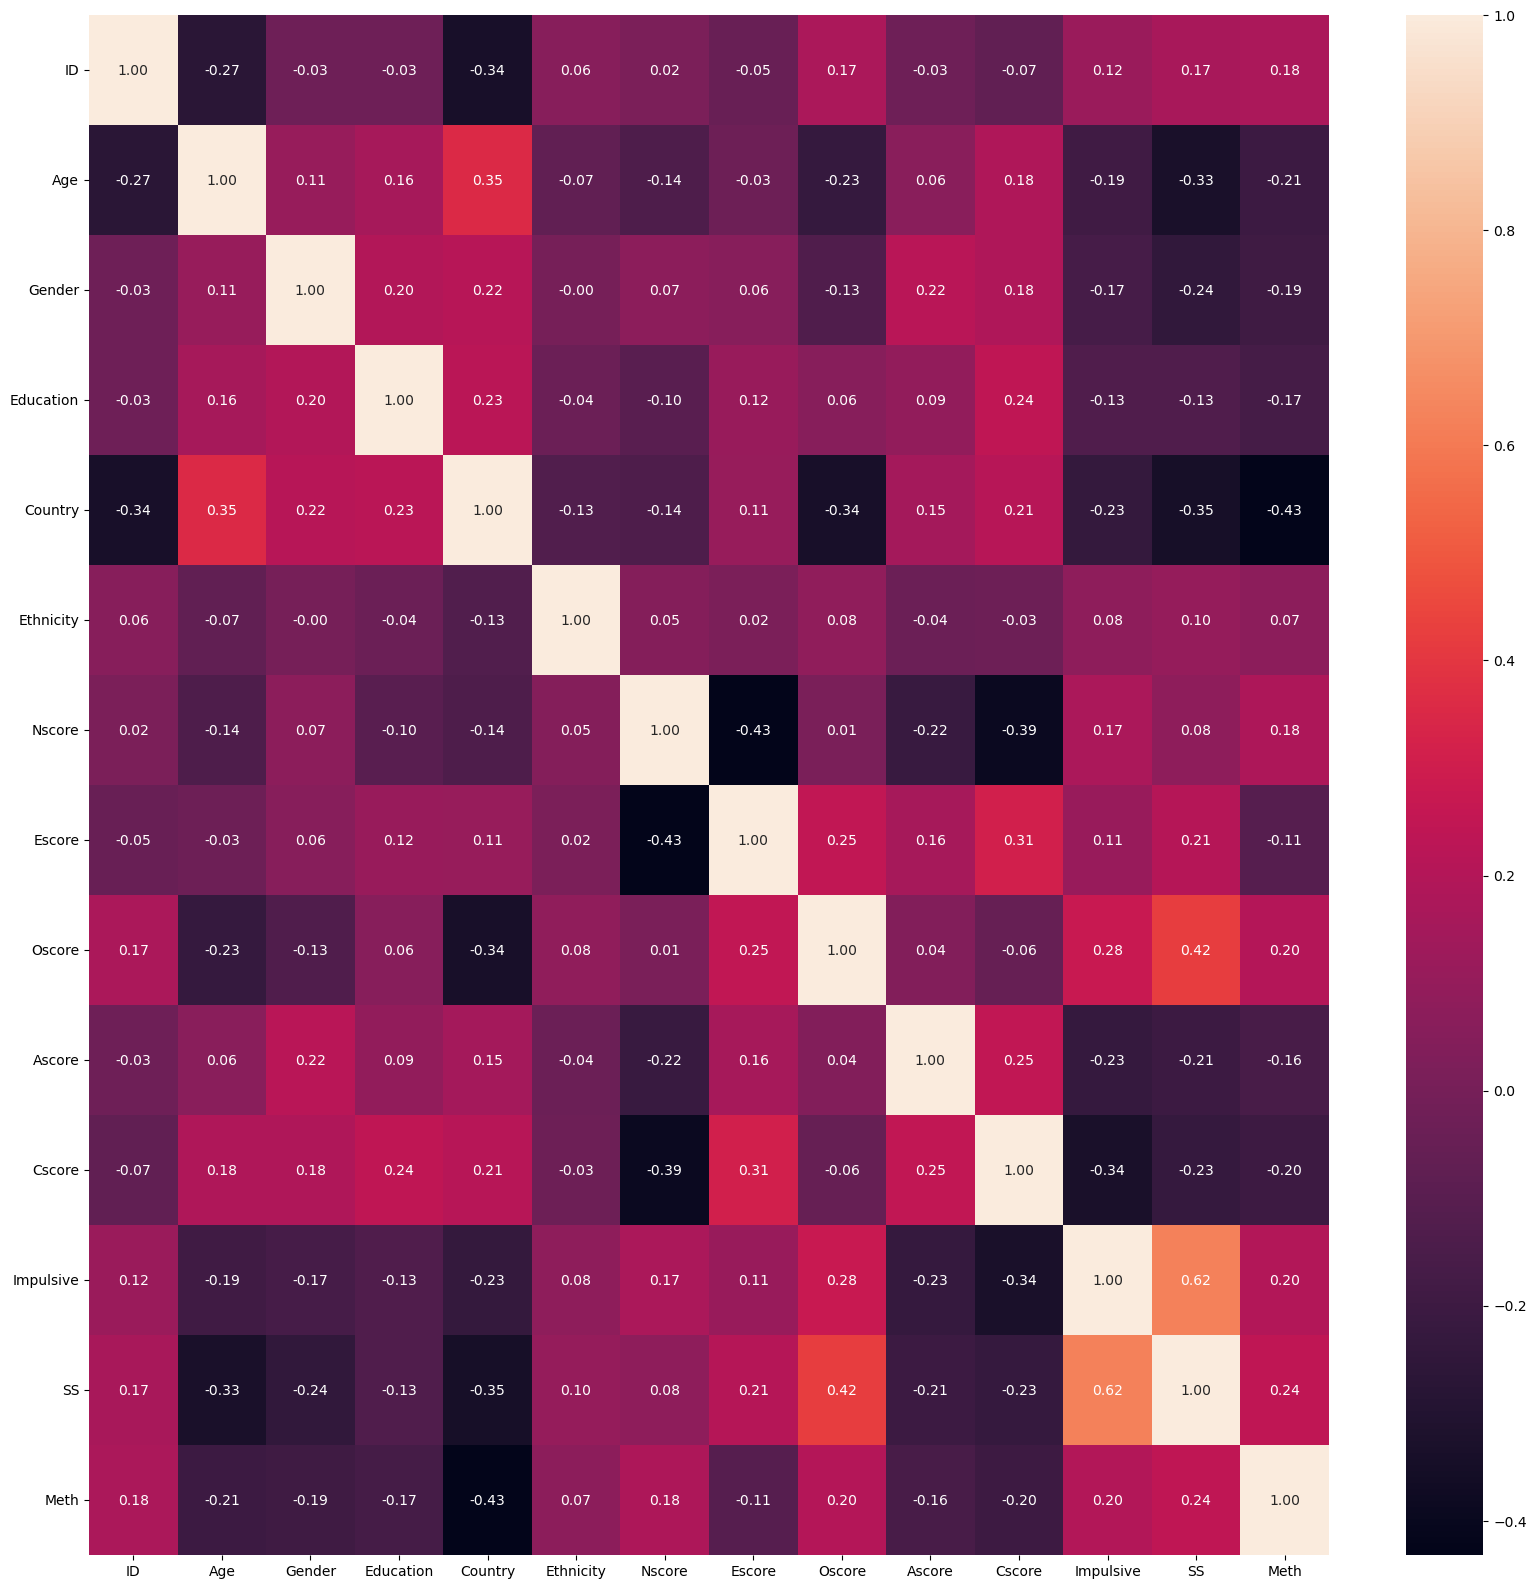

In [85]:
def make_heatmap(df):
    fig, ax = plt.subplots()
    fig.set_size_inches(20, 20)
    ax2 = sns.heatmap(data = df.corr(), annot = True, fmt = '0.2f', ax=ax)
    for item in ax2.get_yticklabels():
        item.set_rotation(0)
    plt.show()

make_heatmap(original_df)

There is no practically no correlation between meth and the ethnicity feature, so this feature will be removed to avoid noise in the model.  
ID feature will alse be removed at it should provide no information, and all the correlation it shows is actually noise.

In [86]:
original_df.drop('Ethnicity', axis = 1, inplace=True)
original_df.drop('ID', axis = 1, inplace=True)

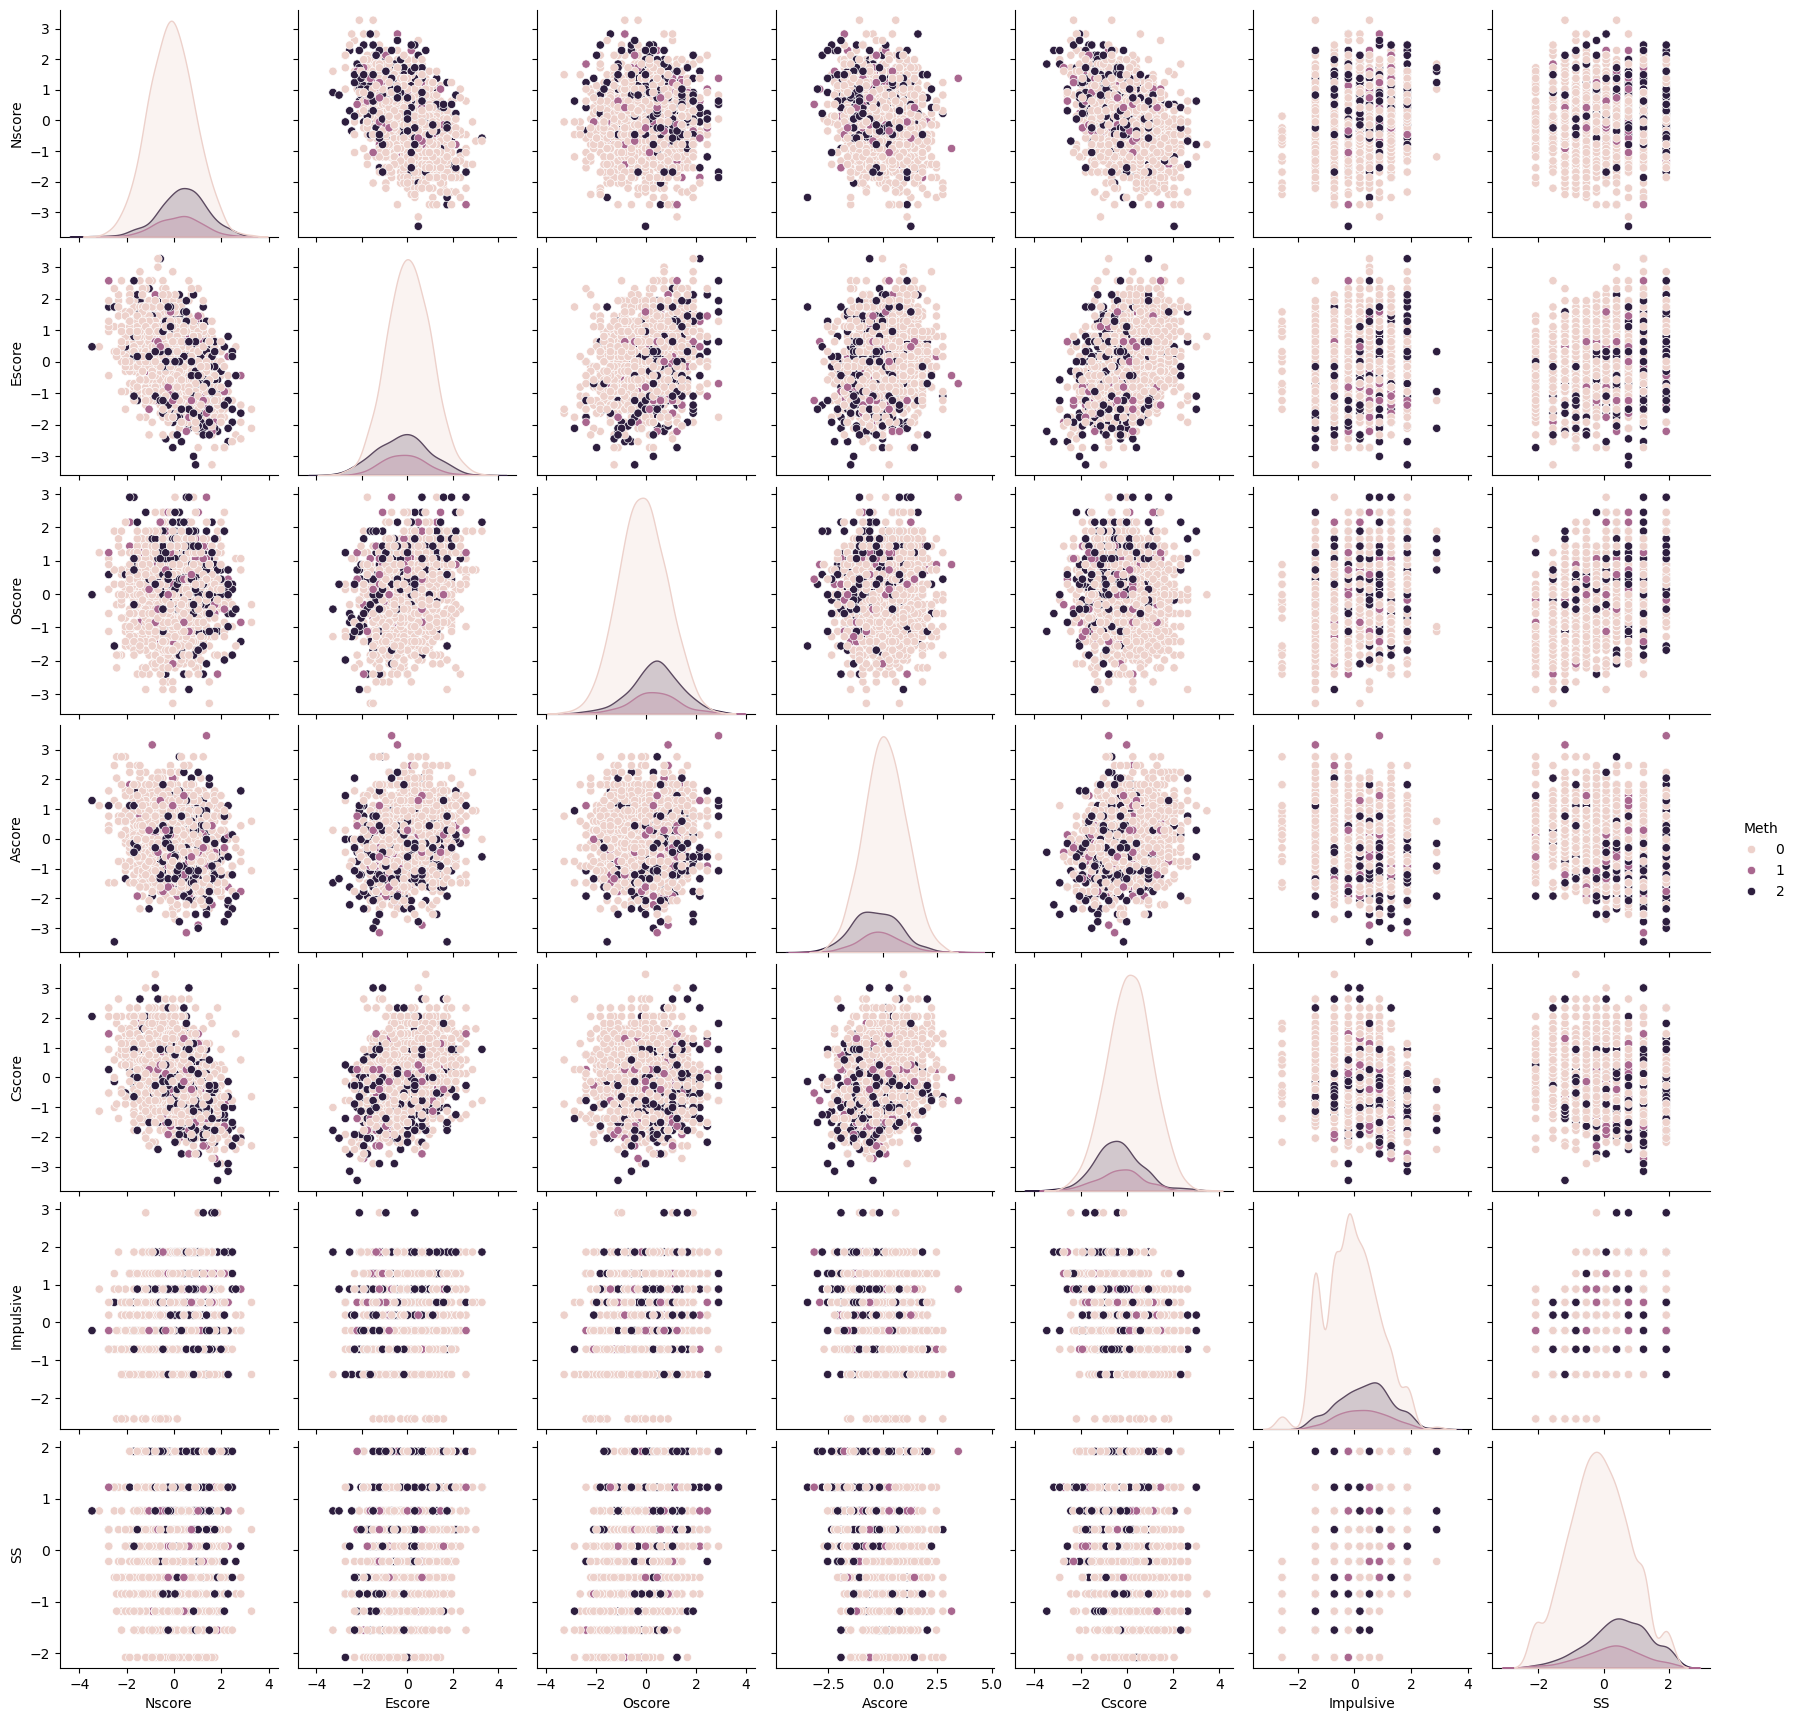

In [87]:
def make_pairplot(df):
    sns.pairplot(df[['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS', 'Meth']], hue='Meth')
    plt.show()

make_pairplot(original_df)

Tho it is possible to see the tendency in the pairplots, the group 0 occupies a very extense area, where the other groups also fall. In simpler terms, in the areas where we observe a bigger concentration of population with a recent consumption of meth, we can also see many people that have not consumed meth. This overlap will most certainly be reduced by a higher dimensional analysis, but still, this visualization is already telling us that in most cases it is easier to identify who IS NOT at risk rather than who IS actually at risk.

The dataset was already distributed using normalized and standardized feature values from the original study; therefore additional scaling was considered unnecessary for this project.

In [88]:
'Data Split'
x = original_df.iloc[ : , :-1]
y = original_df['Meth']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3 , stratify=y, random_state=42)
y_train.value_counts()

Meth
0    1000
2     224
1      95
Name: count, dtype: int64

In [89]:
'Data Resampling'
smt = SMOTETomek(random_state=42)
x_resampled, y_resampled = smt.fit_resample(x_train, y_train)
y_resampled.value_counts()

Meth
1    1000
0     999
2     999
Name: count, dtype: int64

Step 3. ML Model Training and Comparison

In [90]:
def train_knn(x_train, y_train):
    
    clf = KNeighborsClassifier()
    grid_values = {'n_neighbors': [3, 5, 7, 9, 11, 13]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring = 'accuracy', n_jobs=-1)
    grid_clf.fit(x_train, y_train)

    print("KNN Trained")
    return grid_clf

def train_tree(x_train, y_train):
    
    clf = DecisionTreeClassifier()
    grid_values = {'max_depth': [3, 4], 'max_features': [3, 4, 5]}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='accuracy', n_jobs=-1)
    grid_clf.fit(x_train, y_train)

    print("Decision Tree Trained")
    return grid_clf

def train_rforest(x_train, y_train):
    
    clf = RandomForestClassifier(class_weight='balanced', n_jobs=-1)
    grid_values = {'n_estimators': [50, 100, 200], 'min_samples_split': [10, 20], 'max_depth' : [3, 5, 7], 'min_samples_leaf': [4, 6, 10], 'class_weight': ['balanced']}
    grid_clf = GridSearchCV(clf, param_grid = grid_values, scoring='accuracy', n_jobs=-1)
    grid_clf.fit(x_train, y_train)

    print("Random Forest Trained")
    return grid_clf

In [91]:
'Model Training'
knn_clf = train_knn(x_resampled, y_resampled)
tree_clf = train_tree(x_resampled, y_resampled)
rforest_clf = train_rforest(x_resampled, y_resampled)

KNN Trained
Decision Tree Trained
Random Forest Trained


In [92]:
def get_model_scores(models, data, names):

    comparison = dict()
    for model, name in zip(models, names):
        cv_score = cross_val_score(model, data[0], data[2], cv=5, scoring='f1_macro')
        y_predicted = model.predict(data[1])
        y_acc = f1_score(data[3], y_predicted, average='macro')
        comparison[name] = {}
        comparison[name]['Train f1 macro score (CV)'] = float(round(cv_score.mean(), 3))
        comparison[name]['Test f1 macro score'] = round(y_acc, 3)
        print(f'{name} score calculated.....')

    return comparison

In [93]:
'Cross-validation, model comparation and overfitting'
model_scores = get_model_scores((knn_clf, tree_clf, rforest_clf) , (x_resampled, x_test, y_resampled, y_test), ('knn_clf', 'tree_clf', 'rforest_clf'))
print()

for model, scores in model_scores.items():
    print(f"{model}: Train f1 macro score (CV): {scores['Train f1 macro score (CV)']} || Test f1 macro score: {scores['Test f1 macro score']}")

knn_clf score calculated.....
tree_clf score calculated.....
rforest_clf score calculated.....

knn_clf: Train f1 macro score (CV): 0.864 || Test f1 macro score: 0.405
tree_clf: Train f1 macro score (CV): 0.601 || Test f1 macro score: 0.452
rforest_clf: Train f1 macro score (CV): 0.798 || Test f1 macro score: 0.464


--------

In [94]:
def get_feature_importance(model, x_test, y_test, title):

    result = permutation_importance(model, x_test, y_test, n_repeats=10)
    importances = result.importances_mean
    feature_names = x_test.columns

    # Sort feature importances and corresponding names
    sorted_indices = importances.argsort()[::-1]
    sorted_importances = importances[sorted_indices]
    sorted_features = feature_names[sorted_indices]

    plt.figure(figsize=(10, 6))
    plt.barh(sorted_features, sorted_importances)
    plt.xlabel('Permutation Importance')
    plt.title(f'Permutation Importances: {title}')
    plt.show()


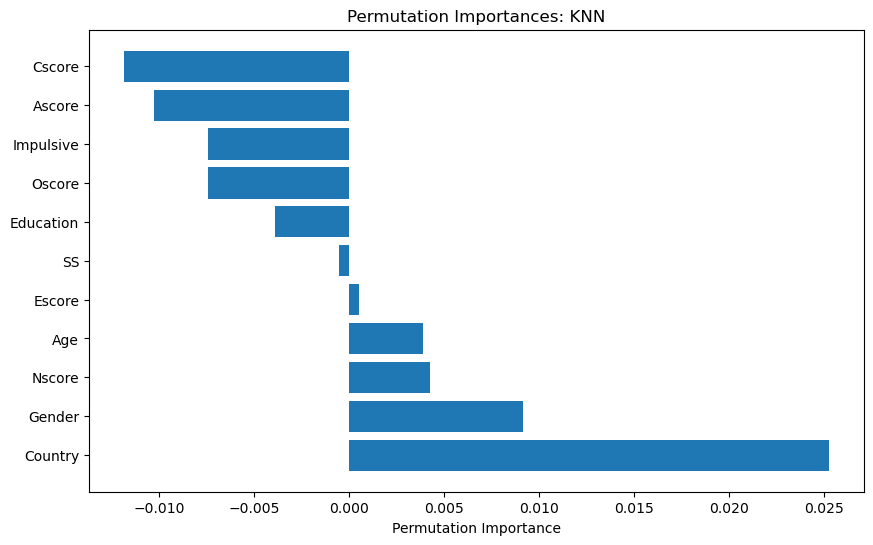

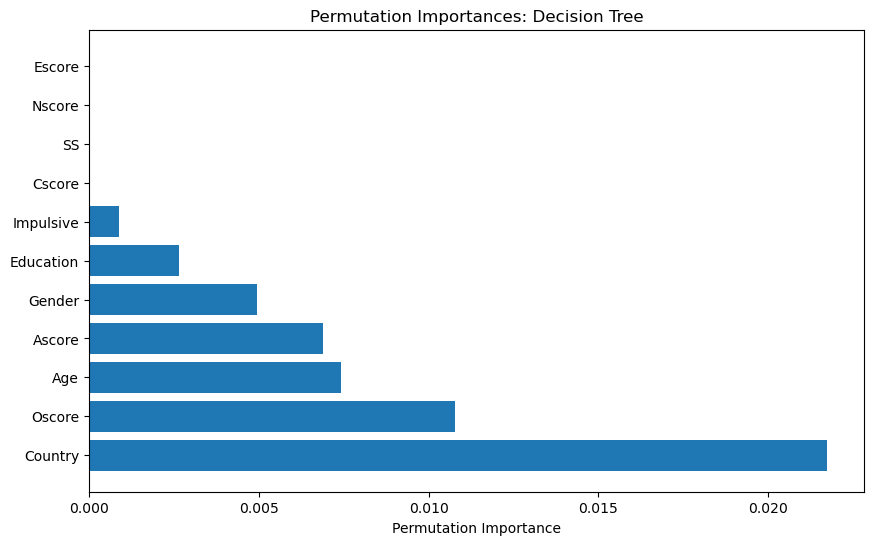

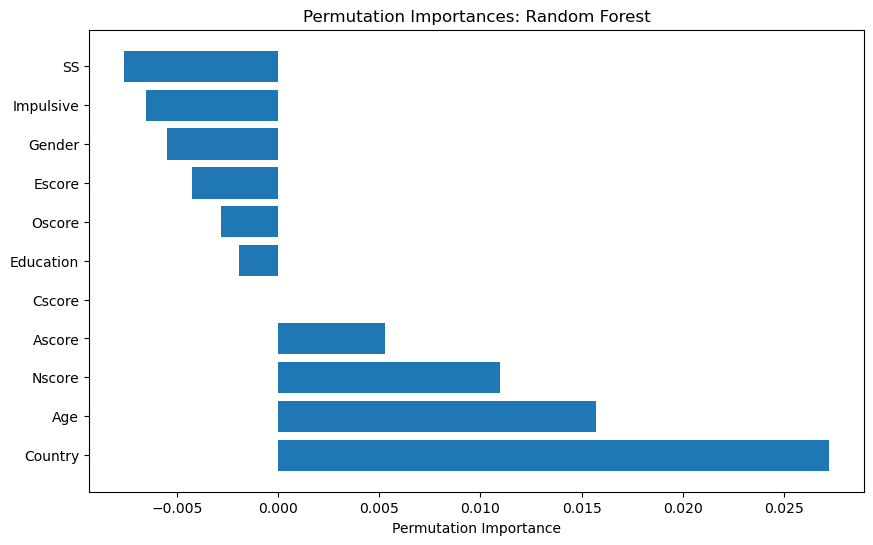

In [95]:
get_feature_importance(knn_clf, x_test, y_test, 'KNN')
get_feature_importance(tree_clf, x_test, y_test, 'Decision Tree')
get_feature_importance(rforest_clf, x_test, y_test, 'Random Forest')

Lastly, feature importance analysis provides insight into how much influence each feature has when predicting the target variable, in this case the risk group associated with Meth consumption. The models showed some common patterns regarding which variables contributed most strongly to the predictions.

Among the demographic variables, both Country and Age consistently appeared as highly influential features across all models. This suggests that demographic context may play a meaningful role in identifying groups at higher risk of Meth consumption.

Regarding the psychological variables, the models showed less agreement. Some models assigned greater importance to Nscore (Neuroticism), while others emphasized Oscore (Openness to Experience) or Cscore (Conscientiousness). However, a more consistent pattern emerged with Ascore (Agreeableness), which appeared to maintain moderate importance across teh three models. This consistency may indicate that Agreeableness has a more stable relationship with the target variable compared to the other personality traits evaluated.